# Recap:
* ## `Scipy` for optimization, root finding, linear programming
# Today's Agenda:
* ## Numerical integration
* ## Solving ODE

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from scipy import linalg as la

## Appliation example:
Imagine you are Mark Watney and now you are stuck on Mars. You have a few options of food to grow on Mars: potatoes, corns and beans. Your goal is to minimize the cost of water in growing food while meeting certain nutrition requirements to survive.

**problem description**

1.	Objective:
Minimize the total cost of water in planting all food.

2.	Constraints:
*	Each food item provides specific amounts of nutrients (e.g., calories, protein, vitamins).
*	The diet must meet or exceed daily requirements for each nutrient.

3.	Variables:

*	Let  $x_i$  represent the amount of the  $i$ -th food item in the diet.

**Mathematical Formulation**
Assume $x_1$ the amount of potato, $x_2$ the amount corn and $x_3$ the amount of beans.
1.	Objective Function:

$$\text{Minimize: } C = c_1 x_1 + c_2 x_2 + \dots + c_n x_n$$

where  $c_i$  is the amount of water needed per unit of food item  $i$ . $c_1= 2, c_2= 3, c_3 = 1.5$.

2.	Constraints:
* Nutritional constraints:

$$a_{11} x_1 + a_{12} x_2 + \dots + a_{1n} x_n \geq b_1 \quad (\text{Calories})$$
$a_{11} = 500, a_{12} = 300, a_{13} =200$


$$a_{21} x_1 + a_{22} x_2 + \dots + a_{2n} x_n \geq b_2 \quad (\text{Protein})$$
$a_{21}= 30,a_{22} = 20, a_{23} =15$
  

$$a_{31} x_1 + a_{32} x_2 + \dots + a_{3n} x_n \geq b_3 \quad (\text{Vitamin})$$
$a_{31}=10, a_{32} =10, a_{33} =10$

*	General form:  $Ax \geq b$ , where  $A$  is the nutrient content matrix.
*	Non-negativity:  $x_i \geq 0$  (you can’t have negative food quantities).

In [ ]:
# Costs (water) of food items (per unit)
cost = [2,3,1.5]  # Cost of potato,corn,beans

# Nutritional content matrix (rows: nutrients, columns: foods)
# Each column represents [calories, protein, vitamins]
A =[[-500,-300,-200], # calories
    [-30,-20,-15],  # proteins
    [-10,-10,-10] # vitamins
    ]

# Nutritional requirements (negative for >= constraint)
b = [-2000,-70,-20]               # Minimum requirements for calories, protein, vitamins

# Bounds for the variables (non-negative food quantities)
x_bounds = [(0,None),(0,None),(0,None)]        # No upper limit for food quantities

# Solve the linear programming problem
result = optimize.linprog(cost, A_ub=A, b_ub=b, bounds=x_bounds,method ='highs')

# Print results
if result.success:
    print("Optimal Food Quantities:", result.x)
    print("Total Cost of Water:", result.fun)
else:
    print("Optimization failed:", result.message)

Optimal Food Quantities: [4. 0. 0.]
Total Cost of Water: 8.0


In [ ]:
?optimize.linprog

### Okay, Potato wins :)

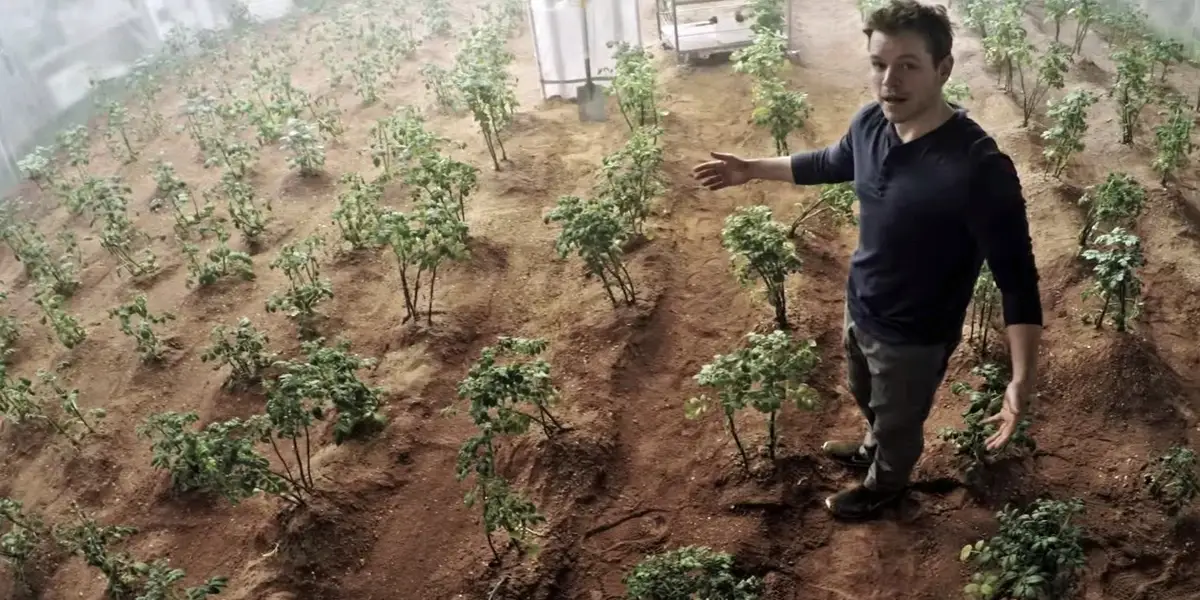

# 1. Numerical integration: `scipy.integrate`

In [ ]:
import scipy.integrate as integ

You can compute integral using the `quad` funtion

In [ ]:
def f(x):
    return 2 * x

In [ ]:
integ.quad(f, 0, 2)  # f and upper and lower bounds
# return value up to an error tolerance this much

(4.0, 4.440892098500626e-14)

In [ ]:
?integ.quad

The `scipy.integrate.quad` function in Python is used for numerical integration (also known as quadrature) of a given function. It calculates the definite integral of a function  $f(x)$  over a specified interval $[a, b]$. The underlying mathematics involves adaptive quadrature methods based on approximating the integral using weighted sums of function evaluations.

**Mathematical Foundation**

* The definite integral of a function  $f(x)$  over an interval $[a, b]$ is given by:

$$I = \int_a^b f(x) \, dx$$


Since this integral cannot always be solved analytically, numerical methods are used to approximate it.

**Numerical Quadrature**

General Quadrature Formula

Numerical quadrature approximates the integral by evaluating  $f(x)$  at a set of points  $x_i$  and applying weights  $w_i$ :

$$I \approx \sum_{i=1}^n w_i f(x_i)$$

where:

*  $x_i$ : Quadrature points (nodes) within $[a, b]$,
*  $w_i$: Weights associated with each quadrature point.

The accuracy of this approximation depends on the choice of points  $x_i$  and weights  $w_i$.

Recall the definition of integral:

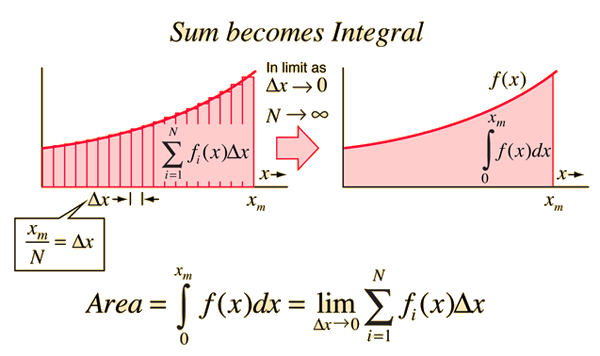

# 2.Solving ODEs using `scipy.integrate`

## You can also solve ODEs of the form
$$ \frac{dy}{dt} = f(y,t) $$
For example
$$\begin{aligned}
&\frac{dy_1(t)}{dt} = ty_2(t)\\
&\frac{dy_2(t)}{dt} = -y_2(t)-9y_1(t)
\end{aligned},\quad \begin{aligned}
&y_1(t=0) = 1\\
&y_2(t=0) = 1\\
\end{aligned}$$

In [ ]:
def f(y, t):  # def function
    return (t * y[1], -y[1] - 9 * y[0])

In [ ]:
?integ.odeint

In [ ]:
# f: Computes the derivative of y at t
# y0 = [1,1] Initial condition on y (can be a vector).
# t: A sequence of time points for which to solve for y.
# Return: Array containing the value of y for each desired time in t,
#         with the initial value y0 in the first row.
time = np.linspace(0, 10, 100)
Y = integ.odeint(f, y0=[1, 1], t=time)

In [ ]:
Y.shape

(100, 2)

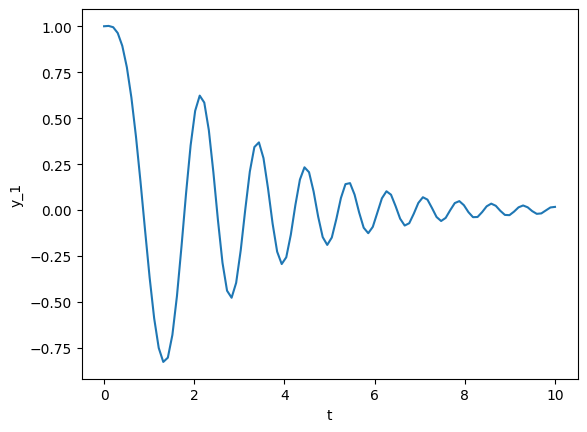

In [ ]:
plt.plot(time, Y[:, 0])
plt.xlabel('t')
plt.ylabel('y_1')
plt.show()

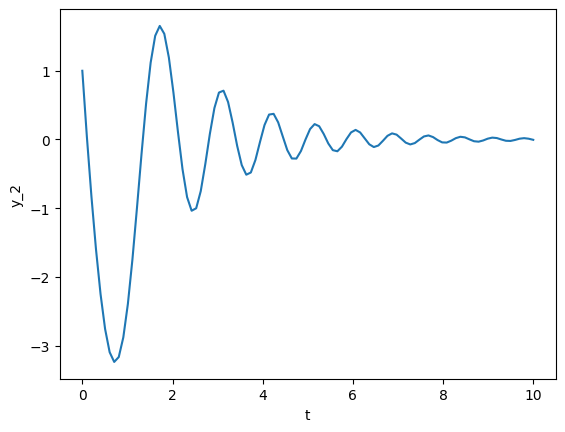

In [ ]:
plt.plot(time, Y[:, 1])
plt.xlabel('t')
plt.ylabel('y_2')
plt.show()

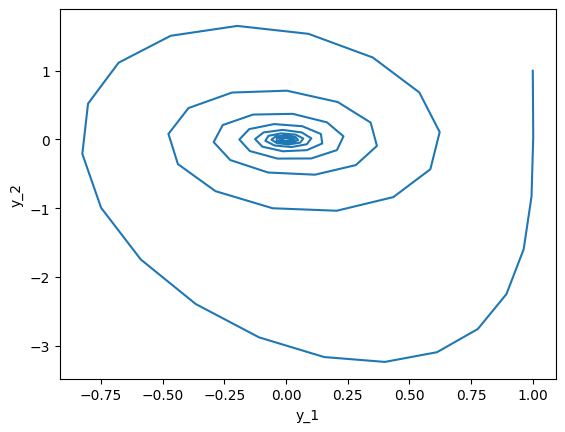

In [ ]:
plt.plot(Y[:, 0], Y[:, 1])
plt.xlabel('y_1')
plt.ylabel('y_2')
plt.show()

## Physical simulation1: throwing a ball
Let's simulate throwing a ball in two dimensions. The ball is described as a function of time by four functions: $x(t), y(t), v_x(t), v_y(t)$, which are governed by the ODE system:

$$
    \frac{dx}{dt} = v_x, \qquad
    \frac{dy}{dt} = v_y, \qquad
    \frac{dv_x}{dt} = 0, \qquad
    \frac{dv_y}{dt} = -g.
$$

We can think of this in vectorized form as:

$$
    \frac{d}{dt} \begin{pmatrix} x \\ y \\ v_x \\ v_y \end{pmatrix} = \begin{pmatrix} v_x \\ v_y \\ 0 \\ -g \end{pmatrix}
$$

In [ ]:
def dzdt(z, t):
    x, y, vx, vy = z
    g = 9.8
    return np.array([vx, vy, 0, -g])

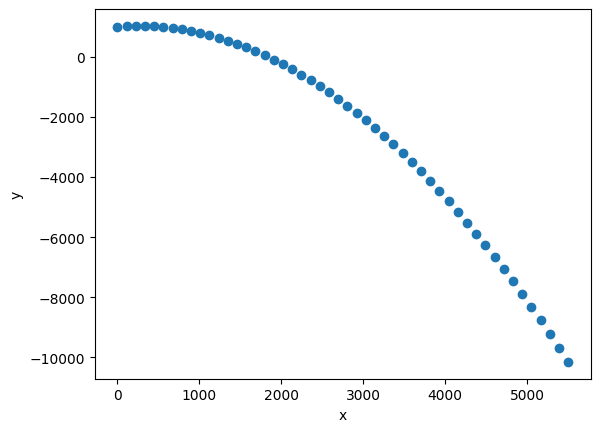

In [ ]:
x0, y0 = 0, 1000
vx0, vy0 = 110, 22

z0 = np.array([x0, y0, vx0, vy0])
t = np.linspace(0, 50, 50)

result = integ.odeint(dzdt, z0, t)

plt.scatter(result[:, 0], result[:, 1])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

We can add drag with the following slight modification to the ODE, which adds a force with direction opposing the current velocity, and with magnitude proportional to the velocity squared.
    
$$
    \frac{d}{dt} \begin{pmatrix} x \\ y \\ v_x \\ v_y \end{pmatrix} = \begin{pmatrix} v_x \\ v_y \\ -\alpha v_x \sqrt{v_x^2 + v_y^2} \\ -g -\alpha v_y \sqrt{v_x^2 + v_y^2} \end{pmatrix}
$$

Implement this with $\alpha = 0.001$, plot the resulting trajectory, and compare to the dragless case.

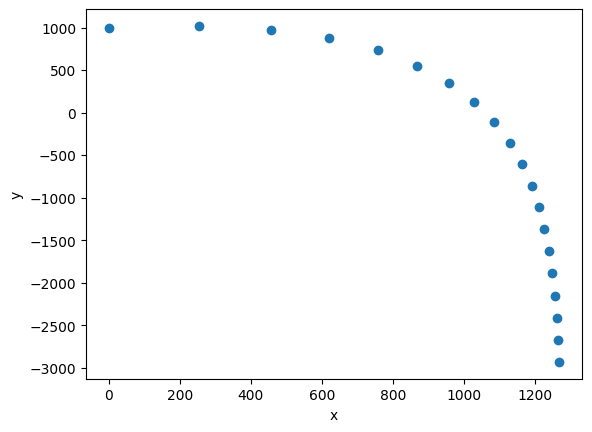

In [ ]:
def dzdt(z,t):
  x,y,vx,vy = z
  g = 9.8
  a = 0.001
  return np.array([vx,vy,0-a*vx*np.sqrt(vx*vx+vy*vy), -g-a*vy*np.sqrt(vx*vx+vy*vy)])
x, y = 0, 1000
vx, vy = 110, 22
z=np.array([x,y,vx,vy])
t = np.linspace(0,50,20)

res = integ.odeint(dzdt, z,t )

plt.scatter(res[:,0], res[:,1])
plt.xlabel('x')
plt.ylabel('y')
plt.show()

## Physical simulation2: Launching a rocket!
* $r(t)$: rocket position
* $v(t)$: rocket velocity

$$\begin{aligned}
&\frac{dr(t)}{dt} = v(t)\\
&\frac{dv(t)}{dt} = f(t)/m-g
\end{aligned}$$
* $f(t)$: force (thruster)
* $m=2$: mass
* $g=9.8$: gravity

The simple model has the following assumptions:
* no atmospheric drag
* rocket only moves vertically
* mass is constant.

Let's also assume the thrust is only on for 5 seconds, then turns off, i.e.,
$$f(t) = \left\{
  \begin{aligned}
  50 &&t\leq 5\\
  0&& t >5
  \end{aligned}
  \right.$$


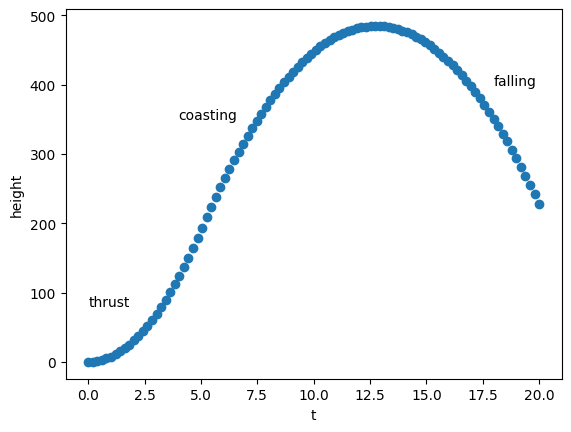

In [ ]:
def rocket_launch(y, t):  # def function
    g = 9.8
    m = 2
    if t <= 5:
      f = 50
    else:
      f = 0
    return np.array([y[1], (f/m - g)])


t = np.linspace(0,20,100)

y0 =  np.array([0,0]) # initial condition

rocket_height = integ.odeint(rocket_launch, y0,np.linspace(0,20,100) )

plt.scatter(t,rocket_height[:,0])
plt.xlabel('t')
plt.ylabel('height')
plt.text(0,80,'thrust')
plt.text(4,350,'coasting')
plt.text(18,400,'falling')
plt.show()